In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [3]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "Age": np.random.randint(21, 60, n),
    "Experience": np.random.randint(0, 35, n),
    "Education": np.random.choice(
        ["Bachelor", "Master", "PhD"],
        n
    ),
    "Department": np.random.choice(
        ["IT", "HR", "Finance", "Marketing"],
        n
    ),
    "Location": np.random.choice(
        ["Dhaka", "Chittagong", "Sylhet"],
        n
    )
})

In [4]:
salary = (
    20000
    + data["Experience"] * 3500
    + data["Age"] * 500
)

salary += data["Education"].map({
    "Bachelor": 0,
    "Master": 15000,
    "PhD": 40000
})

salary += np.random.normal(
    0,
    10000,
    len(data)
)

data["Salary"] = salary

In [5]:
data.to_csv(
    "F:/kaggle projects/7/employee-salary-prediction/data/salary_data.csv",
    index=False
)

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X = data.drop("Salary", axis=1)

y = data["Salary"]

In [8]:
print(X.head())

print(y.head())

   Age  Experience Education Department Location
0   59          33  Bachelor    Finance    Dhaka
1   49          26    Master  Marketing   Sylhet
2   35          16    Master    Finance    Dhaka
3   28          23       PhD         IT   Sylhet
4   41          24    Master         HR    Dhaka
0    146142.330812
1    146561.981316
2     96641.394529
3    131280.435827
4    144918.420893
Name: Salary, dtype: float64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(800, 5)
(200, 5)


In [11]:
X_train_num = X_train[
    ["Age", "Experience"]
]

X_test_num = X_test[
    ["Age", "Experience"]
]

In [12]:
from sklearn.linear_model import LinearRegression

In [13]:
model = LinearRegression()

In [14]:
model.fit(
    X_train_num,
    y_train
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 574.57,3491.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Age','Experience']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.457e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [15]:
print(model.coef_)

[ 574.57460901 3491.94203698]


In [16]:
print(model.intercept_)

34574.60626787739


In [17]:
print(model.intercept_)

34574.60626787739


In [18]:
predictions = model.predict(
    X_test_num
)

In [20]:
print(predictions[:10])

[182559.44620183  59325.8088383  116479.51379669 125761.69630669
 156614.60003048  79128.31184214  58132.16523737 169166.25266293
  71391.87562755  64674.95785103]


In [21]:
print(y_test.head(10).values)

[226784.01986529  50759.01287674 106648.41397303 122522.30955294
 189673.15161359  98662.21129161  77565.94484158 168997.69520606
  70906.54136412  77545.99096991]


In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [23]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = (
    mean_squared_error(
        y_test,
        predictions
    ) ** 0.5
)

r2 = r2_score(
    y_test,
    predictions
)

In [24]:
print("MAE:", mae)

print("RMSE:", rmse)

print("R2:", r2)

MAE: 15962.217102712639
RMSE: 19083.24647460943
R2: 0.7777630600573562


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [26]:
X_num = data[["Age", "Experience"]]
y = data["Salary"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_num,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

In [29]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['Age','Experience']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [30]:
predictions = pipeline.predict(X_test)

In [31]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, predictions)

print(r2)

0.7777630600573562


In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [33]:
X = data.drop("Salary", axis=1)

y = data["Salary"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [35]:
numeric_features = [
    "Age",
    "Experience"
]

In [36]:
categorical_features = [
    "Education",
    "Department",
    "Location"
]

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(),
            categorical_features
        )
    ]
)

In [38]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [39]:
pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['Age','Experience','Education','Department','Location']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated w

In [40]:
predictions = pipeline.predict(
    X_test
)

In [41]:
from sklearn.metrics import r2_score

r2 = r2_score(
    y_test,
    predictions
)

print("R2:", r2)

R2: 0.9428798476638764


In [42]:
from sklearn.model_selection import cross_val_score

In [43]:
scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

In [44]:
print(scores)

[0.93777435 0.94199694 0.93207252 0.93503751 0.95112504]


In [45]:
print(scores.mean())

0.939601272171309


In [46]:
print(scores.std())

0.006623958690653671


In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [48]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

In [49]:
params = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

In [50]:
grid = GridSearchCV(
    ridge_pipeline,
    param_grid=params,
    cv=5,
    scoring="r2"
)

In [51]:
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [52]:
print(grid.best_params_)
print(grid.best_score_)

{'model__alpha': 1}
0.9388304774770079


In [53]:
print(grid.best_estimator_)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Experience']),
                                                 ('cat', OneHotEncoder(),
                                                  ['Education', 'Department',
                                                   'Location'])])),
                ('model', Ridge(alpha=1))])


In [54]:
best_model = grid.best_estimator_

preds = best_model.predict(X_test)

from sklearn.metrics import r2_score

print(r2_score(y_test, preds))

0.9428447143592118


In [55]:
grid.best_params_
grid.best_score_
r2_score(y_test, preds)

0.9428447143592118

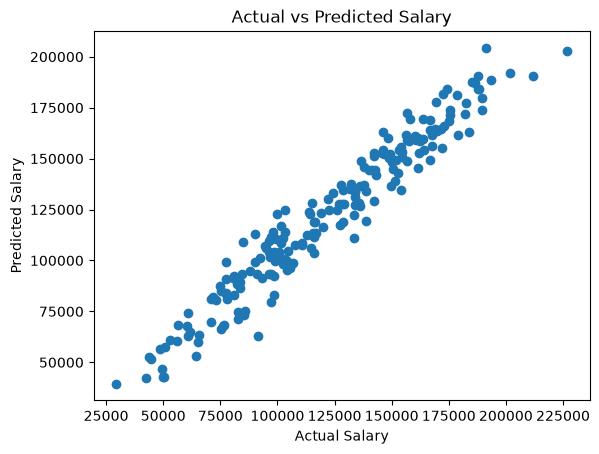

In [56]:
import matplotlib.pyplot as plt

plt.scatter(y_test, preds)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [60]:
import joblib

joblib.dump(
    best_model,
    "F:/kaggle projects/7/employee-salary-prediction/src/salary_predictor.pkl"
)

['F:/kaggle projects/7/employee-salary-prediction/src/salary_predictor.pkl']

In [61]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Experience": [5],
    "Education": ["Master"],
    "Department": ["IT"],
    "Location": ["Dhaka"]
})

prediction = best_model.predict(new_employee)

print(prediction)

[69142.79484389]


In [62]:
model = joblib.load(
    "F:/kaggle projects/7/employee-salary-prediction/src/salary_predictor.pkl"
)

In [63]:
new_employee = pd.DataFrame({
    "Age": [30],
    "Experience": [5],
    "Education": ["Master"],
    "Department": ["IT"],
    "Location": ["Dhaka"]
})

prediction = best_model.predict(new_employee)

print(prediction)

[69142.79484389]
